<a href="https://colab.research.google.com/github/janani-tamilarasan/AI-Resource/blob/main/Machine%20Learning/Decision_Tree/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Decision Tree

### Import Libraries

In [145]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree  import DecisionTreeClassifier,plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score,precision_score,recall_score,classification_report,roc_auc_score,roc_curve

#### Data collection

In [112]:
claimants_data = pd.read_csv("https://raw.githubusercontent.com/janani-tamilarasan/AI-Resource/main/Machine%20Learning/logistic_regression/claimants.csv")
claimants_data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


### Data UnderStanding

In [113]:
print(claimants_data.shape)
print(claimants_data.isna().sum())
print(claimants_data.dtypes)

(1340, 7)
CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64
CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object


### Data Preparation

#### Data cleaning

In [114]:
####  Data cleaning
claimants_data.fillna(value = 0, axis= 1, inplace=True)
claimants_data.isna().sum()

,0
CASENUM,0
ATTORNEY,0
CLMSEX,0
CLMINSUR,0
SEATBELT,0
CLMAGE,0
LOSS,0


### Model Building

#### Split the X and Y

In [115]:
X = claimants_data.filter(('CLMSEX','CLMINSUR','CLMINSUR','SEATBELT','CLMAGE','LOSS'), axis= 1)
Y = claimants_data['ATTORNEY']

#### Train Test Split

In [116]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X,Y,test_size = 0.20,shuffle=True, random_state=34)

#### Model Building

In [148]:
decision_tree_model = DecisionTreeClassifier(criterion='entropy',max_depth=5)

### Model Training

In [149]:
decision_tree_model.fit(X_Train, Y_Train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

### Model Testing

In [150]:
Y_Pred_Train = decision_tree_model.predict(X_Train)
Y_Pred_Train

Y_Pred_Test = decision_tree_model.predict(X_Test)
Y_Pred_Test

array([0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1.,
       0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0.,
       1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0.,
       1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.,
       0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 1.,
       0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1.,
       1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 0.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1.,
       0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0.,
       1., 0., 0., 1., 0.

### Model Evaluation

#### Training Data's Evaluation Metrics

##### Confustion matrix

In [131]:
cm  = confusion_matrix(Y_Train, Y_Pred_Train)
print(cm)


[[429 116]
 [148 379]]


##### Accuracy score

In [132]:
acc_s = accuracy_score(Y_Train, Y_Pred_Train)
print(acc_s)


0.753731343283582


##### Precision

In [133]:
pre_score = precision_score(Y_Train, Y_Pred_Train)
print(pre_score)

0.7656565656565657


##### Classification report

In [151]:
print(classification_report(Y_Train, Y_Pred_Train))

              precision    recall  f1-score   support

         0.0       0.74      0.79      0.76       545
         1.0       0.77      0.71      0.74       527

    accuracy                           0.75      1072
   macro avg       0.75      0.75      0.75      1072
weighted avg       0.75      0.75      0.75      1072



0.7531605243458733


Text(0, 0.5, 'True Positive Rate')

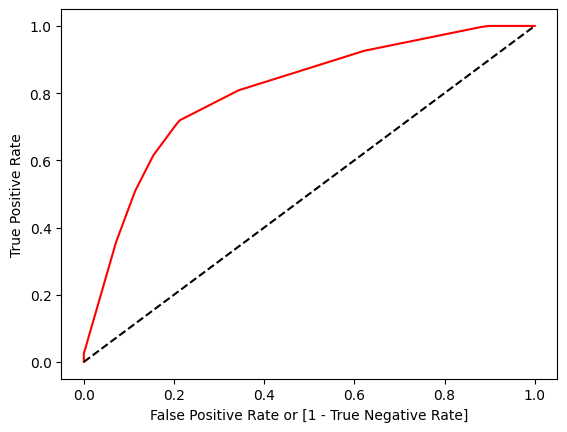

In [141]:
fpr, tpr, thresholds = roc_curve(Y_Train, decision_tree_model.predict_proba (X_Train)[:,1])

auc = roc_auc_score(Y_Train,Y_Pred_Train)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

#### Test Data's Evaluation Metrics

##### Confustion matrix

In [135]:
cm  = confusion_matrix(Y_Test, Y_Pred_Test)
print(cm)


[[108  32]
 [ 44  84]]


##### Accuracy score

In [136]:
acc_s = accuracy_score(Y_Test, Y_Pred_Test)
print(acc_s)


0.7164179104477612


##### Precision

In [137]:
pre_score = precision_score(Y_Test, Y_Pred_Test)
print(pre_score)

0.7241379310344828


##### Classification report

In [152]:
print(classification_report(Y_Test, Y_Pred_Test))

              precision    recall  f1-score   support

         0.0       0.70      0.78      0.74       140
         1.0       0.72      0.63      0.68       128

    accuracy                           0.71       268
   macro avg       0.71      0.71      0.71       268
weighted avg       0.71      0.71      0.71       268



0.7138392857142857


Text(0, 0.5, 'True Positive Rate')

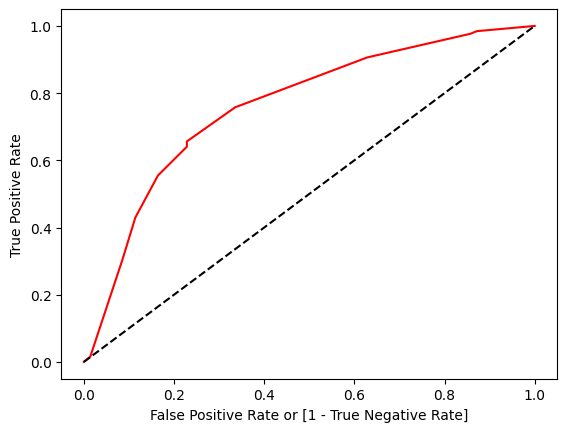

In [142]:
fpr1, tpr1, thresholds1 = roc_curve(Y_Test, decision_tree_model.predict_proba (X_Test)[:,1])

auc = roc_auc_score(Y_Test,Y_Pred_Test)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr1, tpr1, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

### Extras - Grid Search CV(Cross valdation)

In [147]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator  = decision_tree_model,param_grid = {"max_depth":[5,6,7,8,9,10],
                                                                "criterion":['gini','entropy']})
grid_search.fit(X,Y)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5}
0.708955223880597
